### Example 1: From Yellowbrick -documentation (regression)

ResidualsPlot is used to study your dataset and find potnetial error patterns and non-linearity.

This can give you ideas on which ML algorithm to choose, how to optimize or even what to do next with your dataset.

Original code example from:

https://www.scikit-yb.org/en/latest/api/regressor/residuals.html#:~:text=The%20residuals%20plot%20shows%20the,to%20more%20or%20less%20error.&text=A%20common%20use%20of%20the,the%20error%20of%20the%20regressor.

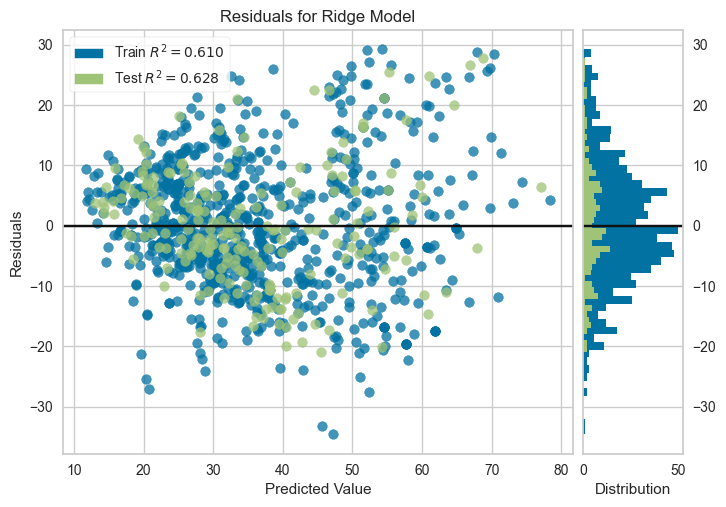

<Axes: title={'center': 'Residuals for Ridge Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [1]:
# pip install yellowbrick

# QUESTION: can we use other models than Ridge too, 
# or can we just replace this with any ML algorithm we want, like XGBoost?
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

from yellowbrick.datasets import load_concrete
from yellowbrick.regressor import ResidualsPlot

# Load a regression dataset
X, y = load_concrete()

# Create the train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate the linear model and visualizer
model = Ridge()
visualizer = ResidualsPlot(model)

visualizer.fit(X_train, y_train)  # Fit the training data to the visualizer
visualizer.score(X_test, y_test)  # Evaluate the model on the test data
visualizer.show()                 # Finalize and render the figure

In [5]:
import pandas as pd

# Convert X (usually numpy array) to DataFrame
df_X = pd.DataFrame(X)

# Convert y (usually numpy array) to Series
df_y = pd.Series(y, name='target')

# Optionally, combine into a single DataFrame
df = pd.concat([df_X, df_y], axis=1)

df


,cement,slag,ash,water,splast,coarse,fine,age,target
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.284354
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.178794
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.696601
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.768036


### Example 2: Let's try our housing data instead

Switched this to XGBoost as in our other examples. Seems to work pretty nicely!

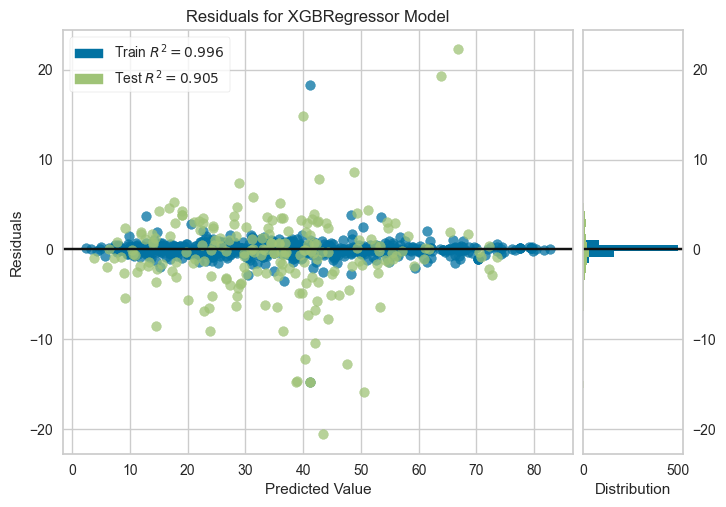

<Axes: title={'center': 'Residuals for XGBRegressor Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [2]:
# pip install yellowbrick

import xgboost as xgb

# QUESTION: can we use other models than Ridge too, 
# or can we just replace this with any ML algorithm we want, like XGBoost?
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

from yellowbrick.datasets import load_concrete
from yellowbrick.regressor import ResidualsPlot

import pandas as pd

# boxplot version
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../houses.csv")

# handle these better with your own dataset, here we are simply dropping these
df = df.drop(['id', 'date', 'zipcode', 'lat', 'long'], axis=1)

# since price is a continuous variable, it's not practical to use it 
# in some of the visualizations. binning creates a categorical variable
# out of a continuous variable, allowing us the use it in visualizations
# this example bins the price into five categories

# Create the train and test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Instantiate the linear model and visualizer
# model = Ridge()

# use GPU-enabled XGBoost Regressor
model = xgb.XGBRegressor(tree_method='gpu_hist')
model.fit(X_train, y_train)

visualizer = ResidualsPlot(model)

visualizer.fit(X_train, y_train)  # Fit the training data to the visualizer
visualizer.score(X_test, y_test)  # Evaluate the model on the test data
visualizer.show()                 # Finalize and render the figure

In [3]:
# ideal case: 
# residuals are randomly scattered around the zero
# no clear patterns or structures in residuals
# residuals have roughly constant variance
# histogram on the side is close to normal distribution

# potential issues:
# non-random patterns => curves, funnels, clusters....  => can imply wrong model or wrong column selection
# residuals spread out or clump tightly as predictions increase => variance is not constant
# non-normal or skewed histogram => errors are not distributed evenly in the model
# large residuals / big outliers => implies huge mistakes made by the model

# since in this case training data works fairly well, but testing data not so much... it implies OVERFITTING